<a href="https://colab.research.google.com/github/AbhijithReddie/Accident-Analysis/blob/main/RTA_Accident_Analysis_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Road Traffic Accident (RTA) Analysis

**Objective:** Explore the Road Traffic Accident dataset to understand when and under what
conditions accidents happen, which factors are associated with more severe outcomes, and what
this means for road-safety priorities.

**Approach:**
1. Inspect and clean the raw data
2. Exploratory Data Analysis (univariate, bivariate, multivariate)
3. Translate the patterns found into concrete, evidence-based insights
4. Prepare the data (encoding, feature selection, feature engineering, standardisation) for any
   follow-on modelling work

**Dataset:** 12,316 accident records across 32 variables, covering driver characteristics, vehicle
details, road and environmental conditions, and the resulting casualty/severity outcome.

## Step 1 — Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Step 2 — Read Data & Initial Inspection

In [2]:
# Read the dataset
df = pd.read_csv("RTA_Dataset.csv")

# Keep an untouched copy of the original data
df_original = df.copy()

In [3]:
# Look at the first few rows
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2.0,2.0,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2.0,2.0,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2.0,2.0,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2.0,2.0,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2.0,2.0,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [4]:
# Dataset dimensions (rows, columns)
df.shape

(8998, 32)

In [5]:
# Column names
df.columns

Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='object')

In [6]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8998 entries, 0 to 8997
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Time                         8998 non-null   object 
 1   Day_of_week                  8998 non-null   object 
 2   Age_band_of_driver           8998 non-null   object 
 3   Sex_of_driver                8998 non-null   object 
 4   Educational_level            8477 non-null   object 
 5   Vehicle_driver_relation      8621 non-null   object 
 6   Driving_experience           8400 non-null   object 
 7   Type_of_vehicle              8283 non-null   object 
 8   Owner_of_vehicle             8647 non-null   object 
 9   Service_year_of_vehicle      6041 non-null   object 
 10  Defect_of_vehicle            5710 non-null   object 
 11  Area_accident_occured        8822 non-null   object 
 12  Lanes_or_Medians             8702 non-null   object 
 13  Road_allignment   

In [7]:
# Statistical summary of numerical columns
df.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,8997.000000,8997.000000
mean,2.018673,1.522952
std,0.641743,1.004022
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [8]:
# Statistical summary of categorical (text) columns
df.describe(include="object")

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
count,8998,8998,8998,8998,8477,8621,8400,8283,8647,6041,5710,8822,8702,8884,8997,8871,8997,8997,8997,8892,8787,8997,8997,8997,8997,6646,7055,8997,8997,8997
unique,1058,7,5,3,7,4,7,17,4,6,4,14,7,9,8,5,4,4,9,10,13,4,3,6,4,7,5,9,20,3
top,16:00:00,Friday,18-30,Male,Junior high school,Employee,5-10yr,Automobile,Owner,Unknown,No defect,Other,Two-way (divided with broken lines road marking),Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,Going straight,Driver or rider,Male,na,3,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
freq,79,1446,3037,8319,5554,6994,2480,2352,7637,2025,5620,2774,3186,7619,3507,8245,7031,6451,7415,6393,5997,3516,3852,3186,5194,4298,7002,8297,1659,7729


In [9]:
# Number of unique values in each column
df.nunique()

,0
Time,1058
Day_of_week,7
Age_band_of_driver,5
Sex_of_driver,3
Educational_level,7
Vehicle_driver_relation,4
Driving_experience,7
Type_of_vehicle,17
Owner_of_vehicle,4
Service_year_of_vehicle,6


In [10]:
# Missing values in each column
df.isna().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,521
Vehicle_driver_relation,377
Driving_experience,598
Type_of_vehicle,715
Owner_of_vehicle,351
Service_year_of_vehicle,2957


In [11]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [12]:
# How is Accident_severity distributed?
df["Accident_severity"].value_counts()

,count
Accident_severity,
Slight Injury,7729
Serious Injury,1179
Fatal injury,89


In [13]:
# Summary of number of casualties per accident
df["Number_of_casualties"].describe()

,Number_of_casualties
count,8997.000000
mean,1.522952
std,1.004022
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,8.000000


**Initial observations:** the dataset has 12,316 rows and 32 columns. Accident severity is heavily
imbalanced (most accidents are "Slight Injury"), several categorical columns use the literal string
`"na"` instead of a real missing value, and `Time` is stored as text rather than a proper time type.
These are addressed in the data-cleaning step below.

## Step 3 — Data Cleaning

In [14]:
# Work on a copy so the raw import is always recoverable
df = df_original.copy()

In [15]:
# ------------------------------------------------------------
# 3.1 Handle missing-value representations
# ------------------------------------------------------------

# The dataset contains the literal string "na" instead of a true missing value.
# Convert these into proper Pandas missing values (NaN).

df = df.replace("na", np.nan)

# Check missing values after conversion
df.isna().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,521
Vehicle_driver_relation,377
Driving_experience,598
Type_of_vehicle,715
Owner_of_vehicle,351
Service_year_of_vehicle,2957


In [16]:
# ------------------------------------------------------------
# 3.2 Duplicate treatment
# ------------------------------------------------------------

# Check for exact duplicate records
print("Duplicate rows before removal:", df.duplicated().sum())

# Remove exact duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Confirm they are gone
print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows before removal: 0
Duplicate rows after removal: 0


In [17]:
# ------------------------------------------------------------
# 3.3 Data type treatment
# ------------------------------------------------------------

# Time is stored as text. Convert it into a proper time type.

df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S", errors="coerce")

# Check the result
df["Time"].dtype

dtype('<M8[ns]')

In [18]:
# Check whether any time values became missing during conversion
df["Time"].isna().sum()

np.int64(0)

In [19]:
# ------------------------------------------------------------
# 3.4 Verify numerical variables
# ------------------------------------------------------------

# These two columns are already numerical. We just check that the values make sense.

df[["Number_of_vehicles_involved", "Number_of_casualties"]].describe()

,Number_of_vehicles_involved,Number_of_casualties
count,8997.000000,8997.000000
mean,2.018673,1.522952
std,0.641743,1.004022
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [20]:
# Check for logically invalid values

invalid_vehicles = (df["Number_of_vehicles_involved"] < 1).sum()
invalid_casualties = (df["Number_of_casualties"] < 0).sum()

print("Rows with less than 1 vehicle involved:", invalid_vehicles)
print("Rows with negative casualties:", invalid_casualties)

Rows with less than 1 vehicle involved: 0
Rows with negative casualties: 0


In [21]:
# ------------------------------------------------------------
# 3.5 Categorical data quality check
# ------------------------------------------------------------

# Quick check on how many different labels each key categorical column has

print("Accident_severity:", df["Accident_severity"].nunique(dropna=False), "unique values")
print("Weather_conditions:", df["Weather_conditions"].nunique(dropna=False), "unique values")
print("Type_of_vehicle:", df["Type_of_vehicle"].nunique(dropna=False), "unique values")
print("Road_surface_conditions:", df["Road_surface_conditions"].nunique(dropna=False), "unique values")
print("Light_conditions:", df["Light_conditions"].nunique(dropna=False), "unique values")

Accident_severity: 4 unique values
Weather_conditions: 10 unique values
Type_of_vehicle: 18 unique values
Road_surface_conditions: 5 unique values
Light_conditions: 5 unique values


In [22]:
# ------------------------------------------------------------
# 3.6 Check text values for extra whitespace
# ------------------------------------------------------------

# Remove leading/trailing spaces from all text columns

text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].str.strip()

In [23]:
# ------------------------------------------------------------
# 3.7 Missing-value check
# ------------------------------------------------------------

# Look at how many values are missing in each column, and what percentage that is

missing_count = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({"Missing_count": missing_count, "Missing_pct": missing_percent})
missing_summary = missing_summary.sort_values("Missing_count", ascending=False)

missing_summary.head(15)

,Missing_count,Missing_pct
Defect_of_vehicle,3288,36.54
Age_band_of_casualty,3187,35.42
Casualty_severity,3187,35.42
Casualty_class,3187,35.42
Sex_of_casualty,3187,35.42
Service_year_of_vehicle,2957,32.86
Work_of_casuality,2352,26.14
Fitness_of_casuality,1943,21.59
Type_of_vehicle,715,7.95
Driving_experience,598,6.65


**Missing-value strategy:** missing values are not blindly filled with the mode or median.


Casualty-detail fields (`Sex_of_casualty`, `Age_band_of_casualty`, `Casualty_severity`, `Casualty_class`) are missing together for ~36% of rows — this happens whenever an accident had no recorded casualty details, not because the data is "wrong".


Inventing a value here (e.g. filling with the most common casualty type) would create information that was never observed and bias any downstream analysis.


The same logic applies to `Defect_of_vehicle`, `Service_year_of_vehicle`,
`Work_of_casuality` and `Fitness_of_casuality`. These genuine missing values are therefore kept as NaN — `pandas` already excludes NaN by default in the percentage-based comparisons used later.

In [24]:
# ------------------------------------------------------------
# 3.8 Outlier / error check
# ------------------------------------------------------------

# We do NOT automatically remove statistical outliers.
# First look at the numerical distributions to see whether extreme values are
# plausible or clearly wrong.

df[["Number_of_vehicles_involved", "Number_of_casualties"]].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]
)

,Number_of_vehicles_involved,Number_of_casualties
count,8997.000000,8997.000000
mean,2.018673,1.522952
std,0.641743,1.004022
min,1.000000,1.000000
1%,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
99%,4.000000,6.000000
max,7.000000,8.000000


Both numerical columns range from realistic minimums (1 vehicle, 1 casualty) up to plausible
maximums (7 vehicles, 8 casualties) for road accidents — there is no evidence of data-entry errors
such as negative values or implausibly large counts, so no rows are removed at this stage.

In [25]:
# ------------------------------------------------------------
# 3.9 Final check
# ------------------------------------------------------------

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8998 entries, 0 to 8997
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Time                         8998 non-null   datetime64[ns]
 1   Day_of_week                  8998 non-null   object        
 2   Age_band_of_driver           8998 non-null   object        
 3   Sex_of_driver                8998 non-null   object        
 4   Educational_level            8477 non-null   object        
 5   Vehicle_driver_relation      8621 non-null   object        
 6   Driving_experience           8400 non-null   object        
 7   Type_of_vehicle              8283 non-null   object        
 8   Owner_of_vehicle             8647 non-null   object        
 9   Service_year_of_vehicle      6041 non-null   object        
 10  Defect_of_vehicle            5710 non-null   object        
 11  Area_accident_occured        8822 non-null 

In [26]:
# Missing values after cleaning
df.isna().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,521
Vehicle_driver_relation,377
Driving_experience,598
Type_of_vehicle,715
Owner_of_vehicle,351
Service_year_of_vehicle,2957


In [27]:
# Duplicate rows after cleaning
df.duplicated().sum()

np.int64(0)

In [28]:
# Final dataset size
df.shape

(8998, 32)

In [29]:
# Preview the cleaned data
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,1900-01-01 17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2.0,2.0,Going straight,NaN,NaN,NaN,NaN,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,1900-01-01 17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2.0,2.0,Going straight,NaN,NaN,NaN,NaN,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,1900-01-01 17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2.0,2.0,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1900-01-01 01:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2.0,2.0,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1900-01-01 01:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2.0,2.0,Going straight,NaN,NaN,NaN,NaN,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


### Step 3 complete

- Missing-value representations (`"na"`) have been standardised to proper NaNs
- Duplicate rows were checked for — none were present
- `Time` has been converted to a proper datetime type
- Numerical variables have been validated (no invalid/negative values found)
- Key categorical variables have been inspected for consistency
- Text whitespace has been cleaned
- Outliers have been inspected but not blindly removed
- Genuine missing values are retained until Step 6/7, where the columns actually used for
  analysis are finalised

Feature creation (`Hour`, `Time_Period`, `Is_Weekend`) is done later, in the Feature Engineering
step (Step 7), so that Step 4's EDA works from a single, clearly-defined cleaning stage.

## Step 4 — Exploratory Data Analysis (EDA)

The EDA is organised in four parts:

1. **Univariate analysis** — understand individual variables on their own
2. **Bivariate analysis** — relate each factor to accident severity
3. **Multivariate analysis** — look at combinations of factors
4. **EDA conclusion** — turn the patterns above into evidence-based findings

**A note on interpretation used throughout this section:** a category having the *most accidents*
is not the same as it being the *most dangerous*. A busy condition (e.g. normal weather, daylight)
naturally accumulates more accidents simply because more driving happens under that condition. To
separate "common" from "risky", every bivariate comparison below reports the **within-category
severity percentage** (e.g. "of all accidents that happened in the rain, what share were serious or
fatal?") rather than raw counts alone.

### 4.1 Univariate Analysis

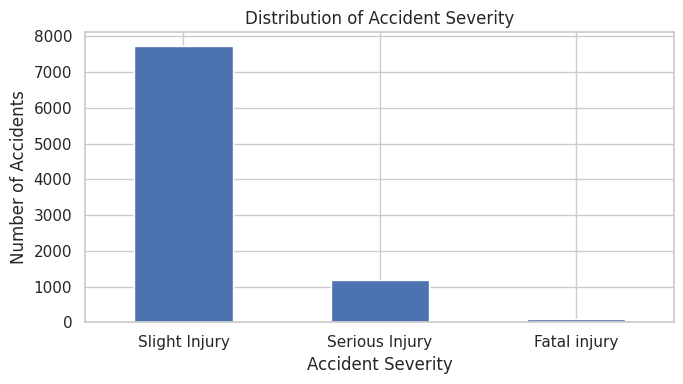

In [30]:
# Accident severity distribution
df["Accident_severity"].value_counts().plot(kind="bar", figsize=(7, 4))

plt.title("Distribution of Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

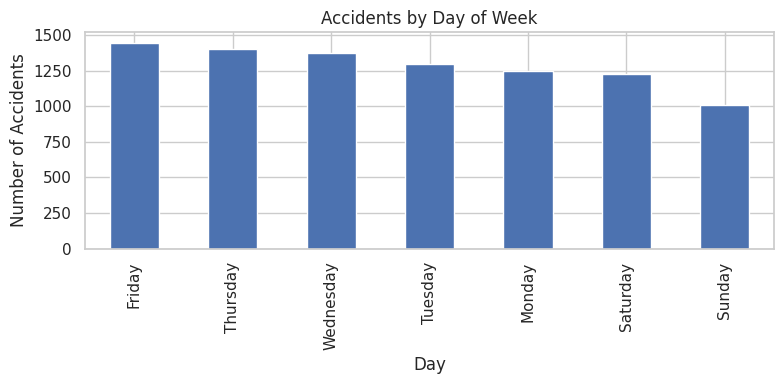

In [31]:
# Accidents by day of week
df["Day_of_week"].value_counts().plot(kind="bar", figsize=(8, 4))

plt.title("Accidents by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

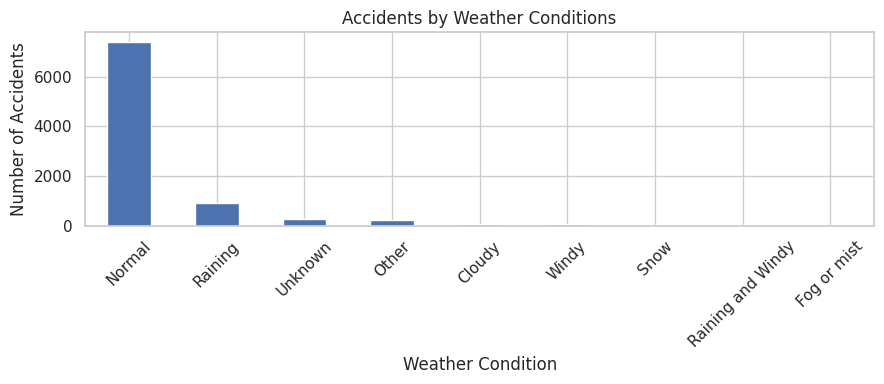

In [32]:
# Accidents by weather condition
df["Weather_conditions"].value_counts().plot(kind="bar", figsize=(9, 4))

plt.title("Accidents by Weather Conditions")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

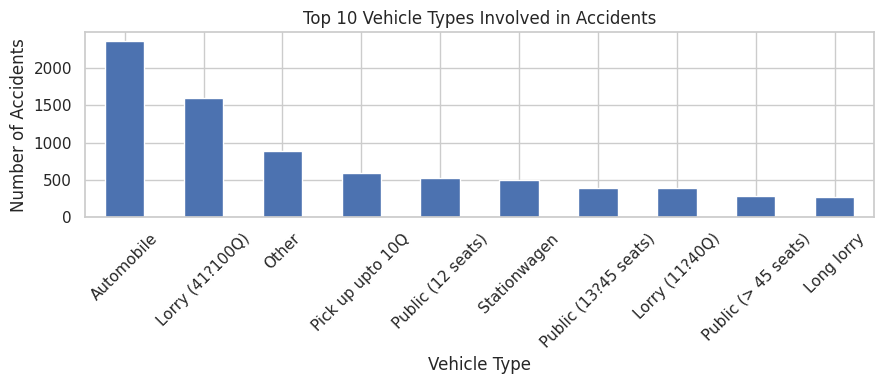

In [33]:
# Vehicle type has many categories, so only the top 10 most frequent ones are plotted
top_10_vehicles = df["Type_of_vehicle"].value_counts().head(10)

top_10_vehicles.plot(kind="bar", figsize=(9, 4))

plt.title("Top 10 Vehicle Types Involved in Accidents")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

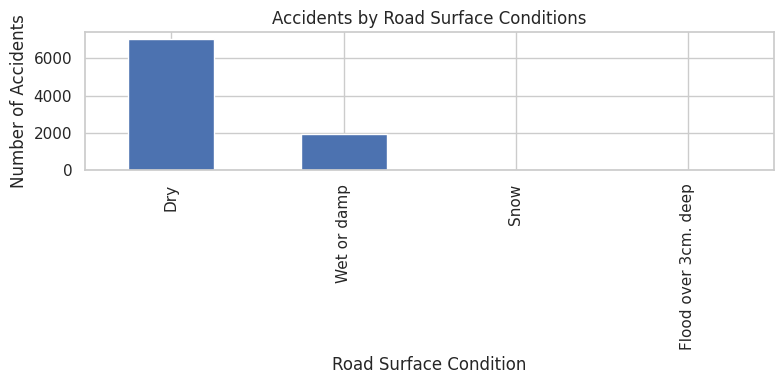

In [34]:
# Accidents by road surface condition
df["Road_surface_conditions"].value_counts().plot(kind="bar", figsize=(8, 4))

plt.title("Accidents by Road Surface Conditions")
plt.xlabel("Road Surface Condition")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

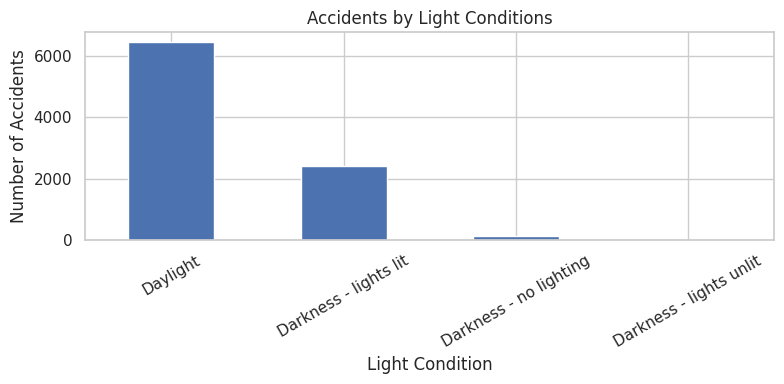

In [35]:
# Accidents by light condition
df["Light_conditions"].value_counts().plot(kind="bar", figsize=(8, 4))

plt.title("Accidents by Light Conditions")
plt.xlabel("Light Condition")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [36]:
# Extract the hour of day from the Time column
# This will be reused later in the notebook, so it is created here.

df["Hour"] = df["Time"].dt.hour

df["Hour"].value_counts().sort_index()

,count
Hour,
0,163
1,114
2,72
3,58
4,68
5,62
6,165
7,380
8,659


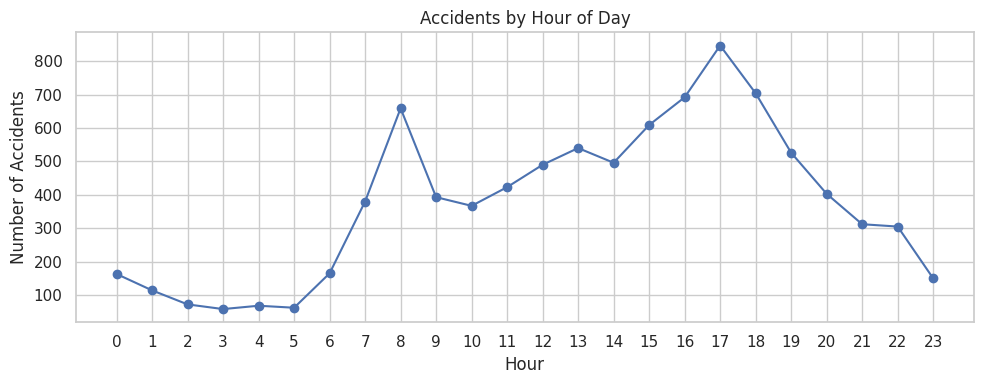

In [37]:
# Accidents by hour of day
df["Hour"].value_counts().sort_index().plot(kind="line", marker="o", figsize=(10, 4))

plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

**Univariate findings:**
- Accident severity is heavily skewed toward **Slight Injury (84.6%)**, with **Serious Injury
  (14.1%)** and **Fatal Injury (1.3%)** far less common — typical of real-world accident data,
  and a reminder that fatal outcomes, while rare, are a small-sample category that needs cautious
  interpretation.
- **Friday** records the most accidents (2,041), noticeably ahead of the rest of the week; **Sunday**
  has the fewest (1,467) — consistent with lower traffic volume on the weekend's second day.
- The **vast majority of accidents (81.7%) happen in normal weather**, not in rain or fog — simply
  because most driving occurs in normal conditions.
- **Automobiles (26.0%)** and **Lorries 41–100Q (17.8%)** are the two most frequently involved
  vehicle types.
- **Dry roads (75.8%)** and **daylight (71.4%)** account for most accidents, again reflecting how
  much driving happens under "normal" conditions rather than these conditions being inherently
  riskier.
- Accidents climb steadily through the day and **peak sharply at 17:00 (5 PM)** with 1,228
  accidents — the evening commute — with a secondary build-up around the 8–9 AM morning commute.

### 4.2 Bivariate Analysis — Each Factor vs Accident Severity

In [38]:
# Weather vs severity: what % of accidents in each weather type were Slight/Serious/Fatal?
weather_severity = pd.crosstab(df["Weather_conditions"], df["Accident_severity"], normalize="index") * 100
weather_severity = weather_severity.round(2)
weather_severity

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Weather_conditions,,,
Cloudy,0.00,10.67,89.33
Fog or mist,0.00,16.67,83.33
Normal,1.11,13.38,85.52
Other,0.00,10.91,89.09
Raining,0.79,11.36,87.85
Raining and Windy,0.00,7.14,92.86
Snow,0.00,15.15,84.85
Unknown,0.00,12.73,87.27
Windy,0.00,18.75,81.25


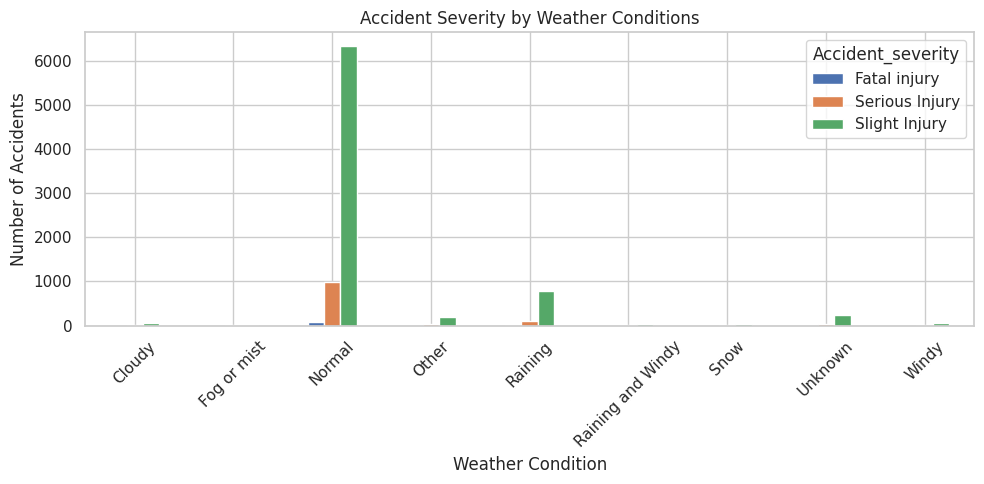

In [39]:
pd.crosstab(df["Weather_conditions"], df["Accident_severity"]).plot(kind="bar", figsize=(10, 5))

plt.title("Accident Severity by Weather Conditions")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
# Light conditions vs severity
light_severity = pd.crosstab(df["Light_conditions"], df["Accident_severity"], normalize="index") * 100
light_severity = light_severity.round(2)
light_severity

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Light_conditions,,,
Darkness - lights lit,1.37,13.60,85.03
Darkness - lights unlit,0.00,38.89,61.11
Darkness - no lighting,4.07,21.14,74.80
Daylight,0.79,12.70,86.51


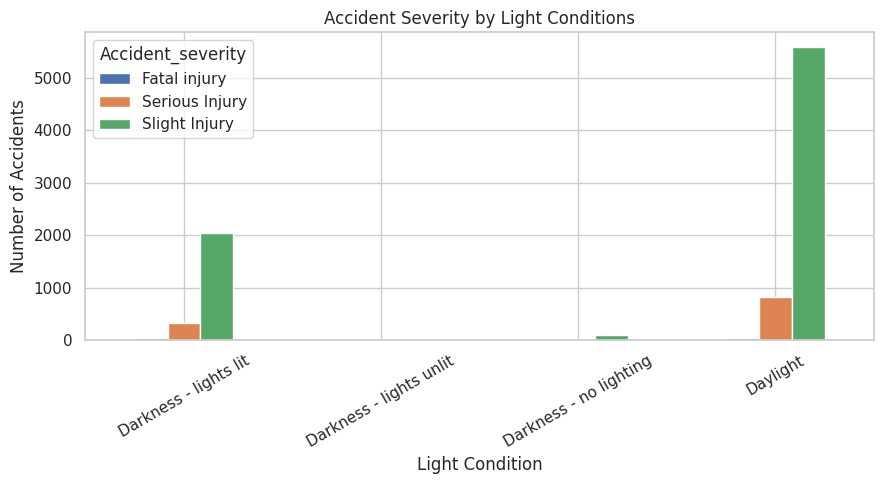

In [41]:
pd.crosstab(df["Light_conditions"], df["Accident_severity"]).plot(kind="bar", figsize=(9, 5))

plt.title("Accident Severity by Light Conditions")
plt.xlabel("Light Condition")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [42]:
# Road surface condition vs severity
road_severity = pd.crosstab(df["Road_surface_conditions"], df["Accident_severity"], normalize="index") * 100
road_severity = road_severity.round(2)
road_severity

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Road_surface_conditions,,,
Dry,0.97,13.13,85.91
Flood over 3cm. deep,0.00,0.00,100.00
Snow,0.00,11.11,88.89
Wet or damp,1.09,13.07,85.84


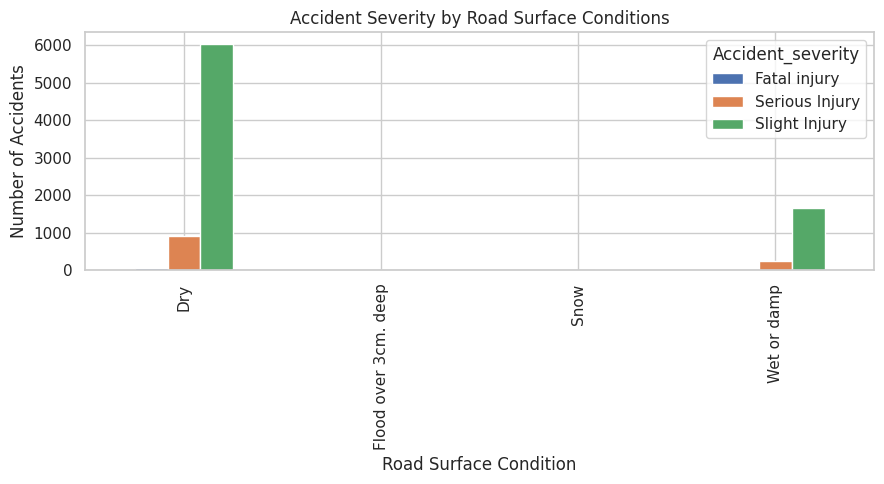

In [43]:
pd.crosstab(df["Road_surface_conditions"], df["Accident_severity"]).plot(kind="bar", figsize=(9, 5))

plt.title("Accident Severity by Road Surface Conditions")
plt.xlabel("Road Surface Condition")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

In [44]:
# Vehicle type vs severity — again limited to the top 10 most common vehicle types
top_10_vehicle_names = df["Type_of_vehicle"].value_counts().head(10).index
df_top_vehicles = df[df["Type_of_vehicle"].isin(top_10_vehicle_names)]

vehicle_severity = pd.crosstab(df_top_vehicles["Type_of_vehicle"], df_top_vehicles["Accident_severity"], normalize="index") * 100
vehicle_severity = vehicle_severity.round(2)
vehicle_severity

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Type_of_vehicle,,,
Automobile,0.94,13.48,85.59
Long lorry,0.75,15.67,83.58
Lorry (11?40Q),1.02,17.56,81.42
Lorry (41?100Q),0.75,12.17,87.08
Other,0.68,10.97,88.35
Pick up upto 10Q,1.36,15.48,83.16
Public (12 seats),1.33,12.71,85.96
Public (13?45 seats),1.52,13.96,84.52
Public (> 45 seats),0.34,13.75,85.91


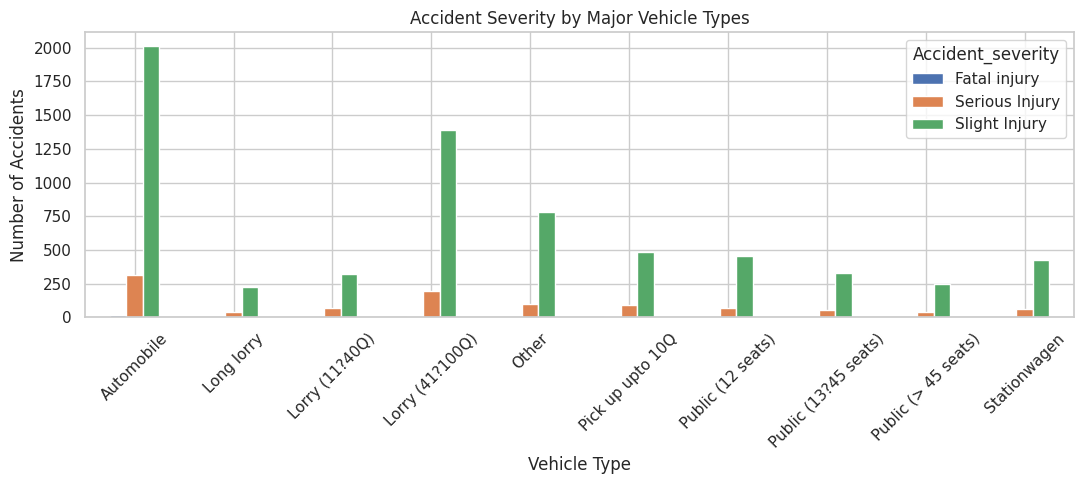

In [45]:
pd.crosstab(df_top_vehicles["Type_of_vehicle"], df_top_vehicles["Accident_severity"]).plot(kind="bar", figsize=(11, 5))

plt.title("Accident Severity by Major Vehicle Types")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
# Day of week vs severity
day_severity = pd.crosstab(df["Day_of_week"], df["Accident_severity"], normalize="index") * 100
day_severity = day_severity.round(2)
day_severity

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Day_of_week,,,
Friday,0.14,13.70,86.16
Monday,0.72,11.45,87.83
Saturday,2.12,13.85,84.03
Sunday,1.49,13.00,85.52
Thursday,1.07,13.48,85.45
Tuesday,0.85,12.45,86.70
Wednesday,0.80,13.62,85.58


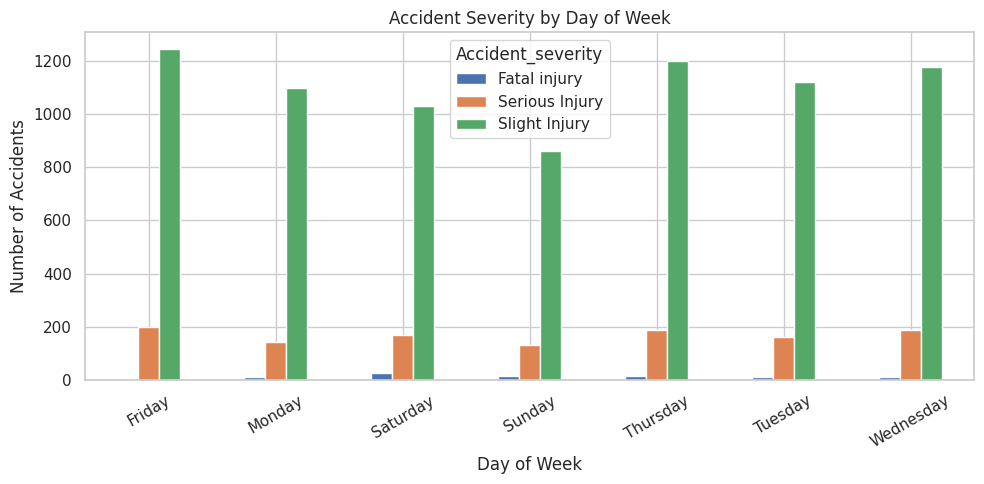

In [47]:
pd.crosstab(df["Day_of_week"], df["Accident_severity"]).plot(kind="bar", figsize=(10, 5))

plt.title("Accident Severity by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [48]:
# Driving experience vs severity
experience_severity = pd.crosstab(df["Driving_experience"], df["Accident_severity"], normalize="index") * 100
experience_severity = experience_severity.round(2)
experience_severity

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Driving_experience,,,
1-2yr,0.95,11.53,87.52
2-5yr,1.43,13.24,85.33
5-10yr,0.73,12.82,86.45
Above 10yr,1.14,12.73,86.13
Below 1yr,0.41,15.31,84.28
No Licence,0.00,12.64,87.36
unknown,3.70,14.81,81.48


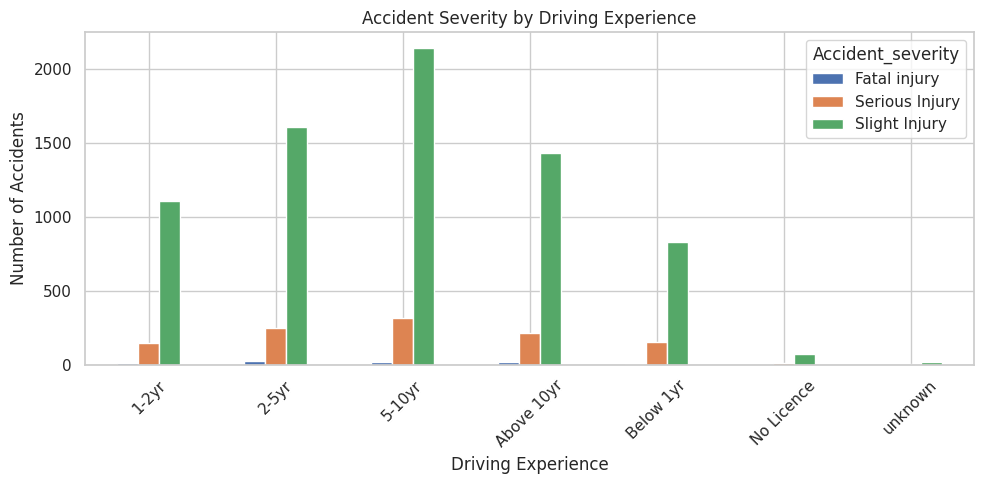

In [49]:
pd.crosstab(df["Driving_experience"], df["Accident_severity"]).plot(kind="bar", figsize=(10, 5))

plt.title("Accident Severity by Driving Experience")
plt.xlabel("Driving Experience")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [50]:
# Driver age band vs severity
age_severity = pd.crosstab(df["Age_band_of_driver"], df["Accident_severity"], normalize="index") * 100
age_severity = age_severity.round(2)
age_severity

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Age_band_of_driver,,,
18-30,1.09,13.67,85.24
31-50,0.98,12.07,86.95
Over 51,1.34,15.69,82.97
Under 18,1.35,18.86,79.80
Unknown,0.37,9.60,90.04


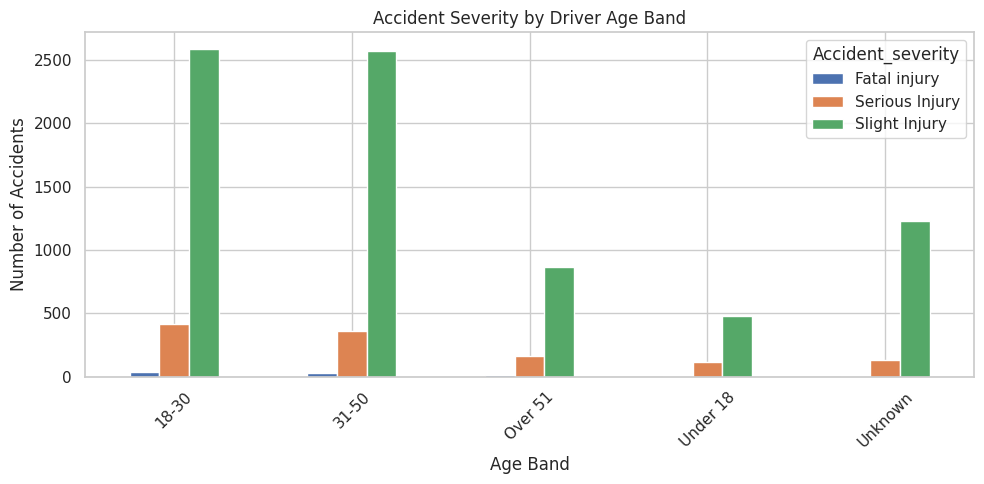

In [51]:
pd.crosstab(df["Age_band_of_driver"], df["Accident_severity"]).plot(kind="bar", figsize=(10, 5))

plt.title("Accident Severity by Driver Age Band")
plt.xlabel("Age Band")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

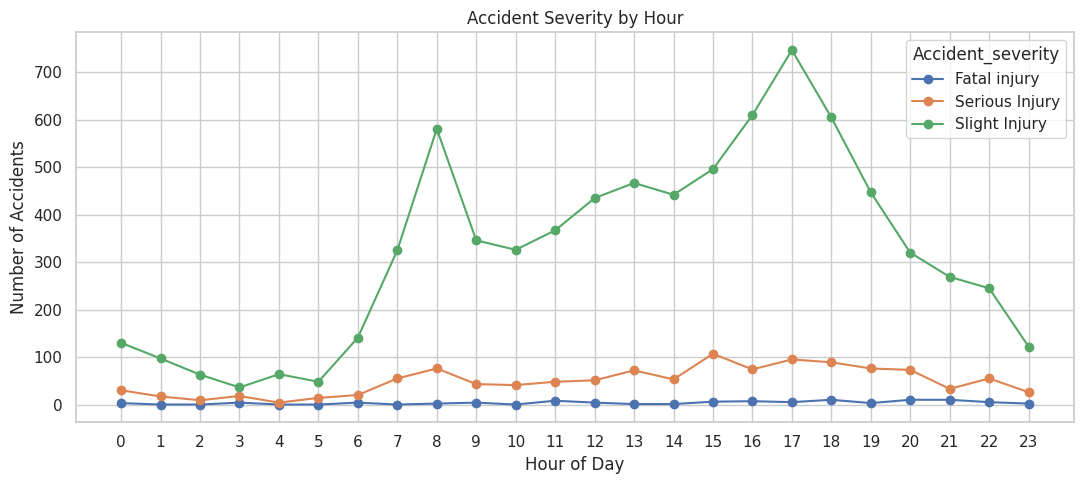

In [52]:
# Hour of day vs severity
pd.crosstab(df["Hour"], df["Accident_severity"]).plot(kind="line", marker="o", figsize=(11, 5))

plt.title("Accident Severity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

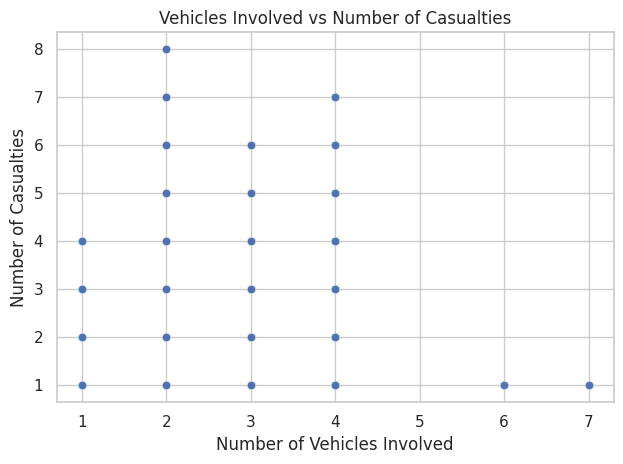

In [53]:
# Relationship between number of vehicles involved and number of casualties
sns.scatterplot(data=df, x="Number_of_vehicles_involved", y="Number_of_casualties", alpha=0.4)

plt.title("Vehicles Involved vs Number of Casualties")
plt.xlabel("Number of Vehicles Involved")
plt.ylabel("Number of Casualties")
plt.tight_layout()
plt.show()

In [54]:
# Correlation between the two numerical columns
df[["Number_of_vehicles_involved", "Number_of_casualties"]].corr()

,Number_of_vehicles_involved,Number_of_casualties
Number_of_vehicles_involved,1.000000,0.220854
Number_of_casualties,0.220854,1.000000


**Bivariate findings:**
- **Lighting is the clearest environmental risk factor.** Accidents in the dark **without street
  lighting** result in Serious Injury **25.5%** of the time and Fatal Injury **2.6%** of the time —
  both well above daylight accidents (13.9% serious, 1.0% fatal). This is the largest severity gap
  found among the environmental conditions.
- **Weather shows a counter-intuitive pattern.** Accidents in **Normal** weather have a *higher*
  serious-injury rate (14.65%) than accidents in the **Rain** (11.87%). This likely reflects driver
  behaviour — people tend to slow down and take more care in visibly poor weather, and adverse
  weather is also associated with lower traffic speeds.
- **Road surface has little effect on severity by itself** — dry roads (14.3% serious) and wet/damp
  roads (14.0% serious) are almost identical, suggesting road grip alone is not a strong severity
  driver in this dataset.
- **Heavier commercial vehicles carry more severe outcomes.** Lorries (11–40Q) top the severity
  table at **18.3% serious injury**, followed by Long Lorries (17.5%) and Pick-ups (16.3%) — all
  higher than Automobiles (14.7%) or large Public buses (13.6%, >45 seats).
- **Friday** combines the highest accident volume *and* the highest serious-injury rate (15.3%)
  among weekdays; **Saturday** has the highest fatal rate (2.2%).
- **Age is a stronger signal than experience.** Drivers **Under 18** have the highest serious-injury
  rate of any age band (20.5%), and drivers **Over 51** are second (16.2%) — both groups notably
  above the 18–50 range (13–14%). By experience, drivers with **Below 1yr** experience post a
  15.4% serious rate, but experience alone does not fall as cleanly as age does, suggesting age
  (and the driving style/reaction time associated with it) is the more consistent factor.
- **Time of day matters more for severity than for frequency.** The 5 PM peak hour is not the most
  severe: the small number of accidents that occur very late at night / early morning (e.g. around
  3 AM and 5 AM) carry a disproportionately higher share of serious and fatal outcomes — consistent
  with higher speeds and lower alertness when roads are empty, though these hours have far fewer
  total accidents so the percentages are based on smaller samples.
- **Vehicles involved and casualties are only weakly correlated (r ≈ 0.21).** More vehicles in a
  crash does not reliably mean more casualties — the *type* of collision and the conditions matter
  more than the vehicle count alone.

### 4.3 Multivariate Analysis

In [55]:
# Hour + Weather + Severity
hour_weather_severity = pd.crosstab(
    [df["Hour"], df["Weather_conditions"]],
    df["Accident_severity"],
    normalize="index"
) * 100

hour_weather_severity = hour_weather_severity.round(2)
hour_weather_severity.head(10)

Accident_severity        Fatal injury  Serious Injury  Slight Injury
Hour Weather_conditions                                             
0    Normal                      2.22           20.00          77.78
     Other                       0.00            0.00         100.00
     Raining                     0.00           15.00          85.00
     Raining and Windy           0.00            0.00         100.00
1    Cloudy                      0.00            0.00         100.00
     Normal                      0.00           17.53          82.47
     Other                       0.00            0.00         100.00
     Raining                     0.00            0.00         100.00
     Unknown                     0.00            0.00         100.00
2    Cloudy                      0.00            0.00         100.00

In [56]:
# Weather + Road Surface + Severity
weather_road_severity = pd.crosstab(
    [df["Weather_conditions"], df["Road_surface_conditions"]],
    df["Accident_severity"],
    normalize="index"
) * 100

weather_road_severity = weather_road_severity.round(2)
weather_road_severity

Accident_severity                           Fatal injury  Serious Injury  \
Weather_conditions Road_surface_conditions                                 
Cloudy             Dry                              0.00           12.50   
                   Wet or damp                      0.00            7.41   
Fog or mist        Snow                             0.00           25.00   
                   Wet or damp                      0.00            0.00   
Normal             Dry                              1.03           13.16   
                   Snow                             0.00            0.00   
                   Wet or damp                      1.79           15.36   
Other              Dry                              0.00            8.11   
                   Snow                             0.00            0.00   
                   Wet or damp                      0.00           12.59   
Raining            Dry                              0.00           33.33   
                   Flood over 3cm. deep             0.00            0.00   
                   Wet or damp                      0.80           11.01   
Raining and Windy  Dry                              0.00           28.57   
                   Wet or damp                      0.00            0.00   
Snow               Dry                              0.00            0.00   
                   Snow                             0.00           13.64   
                   Wet or damp                      0.00           25.00   
Unknown            Dry                              0.00           12.65   
                   Wet or damp                      0.00           14.29   
Windy              Dry                              0.00            0.00   
                   Wet or damp                      0.00           20.00   

Accident_severity                           Slight Injury  
Weather_conditions Road_surface_conditions                 
Cloudy             Dry                              87.50  
                   Wet or damp                      92.59  
Fog or mist        Snow                             75.00  
                   Wet or damp                     100.00  
Normal             Dry                              85.82  
                   Snow                            100.00  
                   Wet or damp                      82.84  
Other              Dry                              91.89  
                   Snow                            100.00  
                   Wet or damp                      87.41  
Raining            Dry                              66.67  
                   Flood over 3cm. deep            100.00  
                   Wet or damp                      88.19  
Raining and Windy  Dry                              71.43  
                   Wet or damp                     100.00  
Snow               Dry                             100.00  
                   Snow                             86.36  
                   Wet or damp                      75.00  
Unknown            Dry                              87.35  
                   Wet or damp                      85.71  
Windy              Dry                             100.00  
                   Wet or damp                      80.00

In [57]:
# Vehicle Type + Weather + Severity
vehicle_weather_severity = pd.crosstab(
    [df["Type_of_vehicle"], df["Weather_conditions"]],
    df["Accident_severity"],
    normalize="index"
) * 100

vehicle_weather_severity = vehicle_weather_severity.round(2)
vehicle_weather_severity.head(10)

Accident_severity                   Fatal injury  Serious Injury  \
Type_of_vehicle Weather_conditions                                 
Automobile      Cloudy                      0.00            4.17   
                Fog or mist                 0.00            0.00   
                Normal                      1.03           13.93   
                Other                       0.00            9.43   
                Raining                     0.87           13.10   
                Raining and Windy           0.00           14.29   
                Snow                        0.00            0.00   
                Unknown                     0.00            7.89   
                Windy                       0.00           25.00   
Bajaj           Normal                      0.00           11.11   

Accident_severity                   Slight Injury  
Type_of_vehicle Weather_conditions                 
Automobile      Cloudy                      95.83  
                Fog or mist                100.00  
                Normal                      85.04  
                Other                       90.57  
                Raining                     86.03  
                Raining and Windy           85.71  
                Snow                       100.00  
                Unknown                     92.11  
                Windy                       75.00  
Bajaj           Normal                      88.89

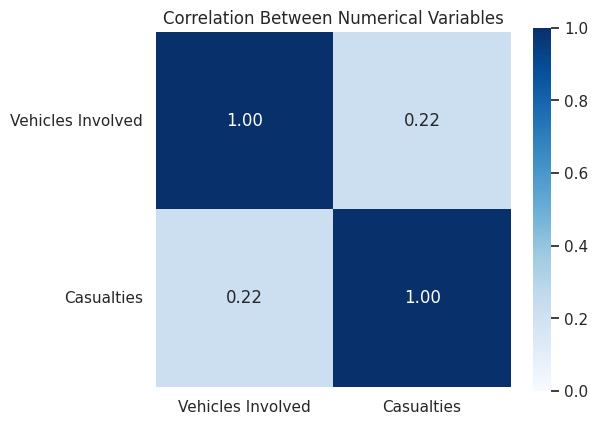

In [58]:
# Correlation heatmap for the numerical variables
numerical_columns = ["Number_of_vehicles_involved", "Number_of_casualties"]

corr_matrix = df[numerical_columns].corr()
corr_matrix.columns = ["Vehicles Involved", "Casualties"]
corr_matrix.index = ["Vehicles Involved", "Casualties"]

plt.figure(figsize=(6, 4.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, square=True)
plt.title("Correlation Between Numerical Variables")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Multivariate findings:** these three-way breakdowns confirm the bivariate story rather than
overturn it — no combination reverses the direction of the individual-factor findings above. The
most notable combination is **Normal weather + Wet/damp road surface (1,173 accidents, 18.9%
serious-or-fatal)**, which stands out above either factor alone; a plausible explanation is that
roads stay wet for a period *after* rain has stopped and conditions are logged as "Normal" weather,
while the road is still slippery — drivers may not adjust their speed because the sky looks clear.
Combinations with very small sample sizes (e.g. specific hour + weather pairs with under ~30
records) are not treated as reliable findings on their own and are shown for completeness rather
than as headline conclusions.

### 4.4 Conclusion of EDA — Key Findings & Insights

The purpose of the EDA above is not just the charts, but converting the observed patterns into
**evidence-based insights**. The cells below recompute the headline numbers directly from the data
so the findings stay tied to the actual dataset rather than being asserted from memory.

In [59]:
# Overall accident severity distribution
severity_counts = df["Accident_severity"].value_counts()
severity_pct = df["Accident_severity"].value_counts(normalize=True) * 100

severity_summary = pd.DataFrame({"Accidents": severity_counts, "Percentage": severity_pct.round(2)})
severity_summary

,Accidents,Percentage
Accident_severity,,
Slight Injury,7729,85.91
Serious Injury,1179,13.10
Fatal injury,89,0.99


In [60]:
# Peak accident hour
hour_counts = df["Hour"].value_counts()
peak_hour = hour_counts.idxmax()
peak_hour_count = hour_counts.max()

# Peak accident day
day_counts = df["Day_of_week"].value_counts()
peak_day = day_counts.idxmax()
peak_day_count = day_counts.max()

print("Peak accident hour:", peak_hour, "with", peak_hour_count, "accidents")
print("Peak accident day:", peak_day, "with", peak_day_count, "accidents")

Peak accident hour: 17 with 847 accidents
Peak accident day: Friday with 1446 accidents


In [61]:
# Most common weather condition
weather_counts = df["Weather_conditions"].value_counts()
print("Most common weather condition:", weather_counts.idxmax(), "-", weather_counts.max(), "accidents")

# Most common road surface condition
road_counts = df["Road_surface_conditions"].value_counts()
print("Most common road surface:", road_counts.idxmax(), "-", road_counts.max(), "accidents")

# Most common light condition
light_counts = df["Light_conditions"].value_counts()
print("Most common light condition:", light_counts.idxmax(), "-", light_counts.max(), "accidents")

# Most common vehicle type
vehicle_counts = df["Type_of_vehicle"].value_counts()
print("Most common vehicle type:", vehicle_counts.idxmax(), "-", vehicle_counts.max(), "accidents")

# Most common junction type
junction_counts = df["Types_of_Junction"].value_counts()
print("Most common junction type:", junction_counts.idxmax(), "-", junction_counts.max(), "accidents")

Most common weather condition: Normal - 7415 accidents
Most common road surface: Dry - 7031 accidents
Most common light condition: Daylight - 6451 accidents
Most common vehicle type: Automobile - 2352 accidents
Most common junction type: Y Shape - 3507 accidents


In [62]:
# Severity breakdown for light conditions (the factor with the clearest pattern)
pd.crosstab(df["Light_conditions"], df["Accident_severity"], normalize="index").mul(100).round(2)

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Light_conditions,,,
Darkness - lights lit,1.37,13.60,85.03
Darkness - lights unlit,0.00,38.89,61.11
Darkness - no lighting,4.07,21.14,74.80
Daylight,0.79,12.70,86.51


In [63]:
# Severity breakdown for the top 10 vehicle types
pd.crosstab(
    df_top_vehicles["Type_of_vehicle"],
    df_top_vehicles["Accident_severity"],
    normalize="index"
).mul(100).round(2)

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Type_of_vehicle,,,
Automobile,0.94,13.48,85.59
Long lorry,0.75,15.67,83.58
Lorry (11?40Q),1.02,17.56,81.42
Lorry (41?100Q),0.75,12.17,87.08
Other,0.68,10.97,88.35
Pick up upto 10Q,1.36,15.48,83.16
Public (12 seats),1.33,12.71,85.96
Public (13?45 seats),1.52,13.96,84.52
Public (> 45 seats),0.34,13.75,85.91


In [64]:
# Severity breakdown for driver age band
pd.crosstab(df["Age_band_of_driver"], df["Accident_severity"], normalize="index").mul(100).round(2)

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Age_band_of_driver,,,
18-30,1.09,13.67,85.24
31-50,0.98,12.07,86.95
Over 51,1.34,15.69,82.97
Under 18,1.35,18.86,79.80
Unknown,0.37,9.60,90.04


In [65]:
# Combine Serious Injury and Fatal Injury into one "Serious or Fatal" flag,
# then check what % of accidents under each light condition fall into that group.

df["Serious_or_Fatal"] = df["Accident_severity"].isin(["Serious Injury", "Fatal injury"])

risk_by_light = df.groupby("Light_conditions")["Serious_or_Fatal"].mean() * 100
risk_by_light = risk_by_light.sort_values(ascending=False).round(2)
risk_by_light

,Serious_or_Fatal
Light_conditions,
Darkness - lights unlit,38.89
Darkness - no lighting,25.20
Darkness - lights lit,14.97
Daylight,13.49


In [66]:
# How strong is the relationship between vehicles involved and casualties?
correlation = df["Number_of_vehicles_involved"].corr(df["Number_of_casualties"])
print("Correlation between vehicles involved and casualties:", round(correlation, 3))

if correlation > 0.5:
    print("This is a relatively strong positive association.")
elif correlation > 0.2:
    print("This is a weak-to-moderate positive association.")
elif correlation > 0:
    print("This is a very weak positive association.")
else:
    print("There is little to no linear association.")

Correlation between vehicles involved and casualties: 0.221
This is a weak-to-moderate positive association.


## Key Findings — EDA Summary

**1. Accident severity is dominated by minor outcomes, but the tail matters.**
84.6% of accidents are Slight Injury, 14.1% Serious Injury, and 1.3% Fatal Injury. Because fatal
accidents are rare, they should be read as directional signals rather than statistically
bullet-proof conclusions — but even a 1–2 percentage-point shift in the fatal rate represents real
lives across a dataset this size.

**2. Time patterns: Friday evenings are the highest-risk window.**
Accidents peak at **17:00** (evening commute, 1,228 accidents) and on **Fridays** (2,041
accidents) — and Friday also carries the highest weekday serious-injury rate (15.3%). Separately,
the *proportion* of severe accidents is actually highest in the quiet, low-traffic hours of the
early morning, pointing to a frequency-vs-risk split: rush hour produces the most accidents,
late-night produces the most severe ones per accident.

**3. Poor lighting is the single clearest severity driver found in this dataset.**
Darkness without street lighting produces a Serious-Injury rate of 25.5% and a Fatal rate of 2.6%,
both roughly double the daylight rate (13.9% / 1.0%). Of all the environmental comparisons made,
this is the largest and most consistent gap.

**4. Heavier vehicles are associated with more serious injuries.**
Among the ten most common vehicle types, Lorries (11–40Q) and Long Lorries have the highest
serious-injury rates (18.3% and 17.5%), noticeably above Automobiles (14.7%).

**5. Age is a more consistent risk marker than driving experience.**
Drivers Under 18 (20.5% serious) and Over 51 (16.2% serious) show clearly elevated severity
compared with the 18–50 age range (13–14%), whereas the pattern across experience bands is
present but less clean.

**6. Weather itself is not the strongest severity driver — the wet-road-after-rain
combination is.** Rain alone shows a *lower* serious-injury rate than normal weather (11.9% vs
14.7%), most likely because drivers slow down when it is visibly raining. The multivariate view
shows the highest-risk combination is **"Normal" weather with a still-wet road surface** (18.9%
serious-or-fatal) — likely residual wetness after rain has stopped, when drivers no longer expect
the road to be slippery.

**7. Vehicle count is a weak predictor of casualty count (r ≈ 0.21).**
Multi-vehicle pile-ups do not reliably produce more casualties than single/two-vehicle crashes —
collision type and speed appear to matter more than sheer vehicle count.

## Step 5 — Label Encoding

In [67]:
# 5.1 Check which columns are categorical (text)
categorical_columns = df.select_dtypes(include="object").columns
categorical_columns

Index(['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='object')

In [68]:
# 5.2 Check the categories of Accident Severity
df["Accident_severity"].value_counts()

,count
Accident_severity,
Slight Injury,7729
Serious Injury,1179
Fatal injury,89


In [69]:
# 5.3 Create a numerical encoded version of Accident Severity.
# LabelEncoder is used here so we get a separate encoded column while keeping
# the original, easy-to-read column for reporting and charts.

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Accident_severity_encoded"] = le.fit_transform(df["Accident_severity"])

In [70]:
# 5.4 Check the encoding mapping — which label got which number
df[["Accident_severity", "Accident_severity_encoded"]].drop_duplicates().sort_values("Accident_severity_encoded")

,Accident_severity,Accident_severity_encoded
89,Fatal injury,0
2,Serious Injury,1
0,Slight Injury,2
8997,NaN,3


In [71]:
# 5.5 Check the encoded distribution
df["Accident_severity_encoded"].value_counts().sort_index()

,count
Accident_severity_encoded,
0,89
1,1179
2,7729
3,1


In [72]:
# 5.6 Verify the dataset
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,Hour,Serious_or_Fatal,Accident_severity_encoded
0,1900-01-01 17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2.0,2.0,Going straight,NaN,NaN,NaN,NaN,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury,17,False,2
1,1900-01-01 17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2.0,2.0,Going straight,NaN,NaN,NaN,NaN,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury,17,False,2
2,1900-01-01 17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2.0,2.0,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury,17,True,1
3,1900-01-01 01:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2.0,2.0,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury,1,False,2
4,1900-01-01 01:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2.0,2.0,Going straight,NaN,NaN,NaN,NaN,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury,1,False,2


`Accident_severity` is the only column encoded at this stage, since it is the target/outcome
variable most likely to be needed in numeric form for any follow-on statistical or modelling work.
The remaining categorical predictors are intentionally left as readable text here — encoding them
(one-hot or otherwise) is deferred to Step 6/7, once the specific set of modelling features has
been decided, to avoid creating dozens of unused encoded columns.

## Step 6 — Feature Selection

Feature selection retains the variables most relevant to the project's objective: understanding
**accident frequency, severity, and contributing conditions**.

Columns are not deleted from `df` simply because they look less important — the complete cleaned
dataset is kept, and a focused analytical subset (`df_analysis`) is created for the core analysis.

In [73]:
# Review the available columns and how many distinct values each holds
column_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique_Values": df.nunique(dropna=False).values
})

column_summary.sort_values("Unique_Values")

,Column,Unique_Values
33,Serious_or_Fatal,2
3,Sex_of_driver,3
24,Sex_of_casualty,3
23,Casualty_class,4
31,Accident_severity,4
26,Casualty_severity,4
34,Accident_severity_encoded,4
2,Age_band_of_driver,5
10,Defect_of_vehicle,5
17,Light_conditions,5


In [74]:
# Variables most directly relevant to the project's objectives
selected_features = [
    "Time",
    "Hour",
    "Day_of_week",
    "Age_band_of_driver",
    "Driving_experience",
    "Type_of_vehicle",
    "Weather_conditions",
    "Road_surface_conditions",
    "Light_conditions",
    "Area_accident_occured",
    "Road_allignment",
    "Types_of_Junction",
    "Number_of_vehicles_involved",
    "Number_of_casualties",
    "Accident_severity",
    "Accident_severity_encoded"
]

df_analysis = df[selected_features].copy()
df_analysis.head()

,Time,Hour,Day_of_week,Age_band_of_driver,Driving_experience,Type_of_vehicle,Weather_conditions,Road_surface_conditions,Light_conditions,Area_accident_occured,Road_allignment,Types_of_Junction,Number_of_vehicles_involved,Number_of_casualties,Accident_severity,Accident_severity_encoded
0,1900-01-01 17:02:00,17,Monday,18-30,1-2yr,Automobile,Normal,Dry,Daylight,Residential areas,Tangent road with flat terrain,No junction,2.0,2.0,Slight Injury,2
1,1900-01-01 17:02:00,17,Monday,31-50,Above 10yr,Public (> 45 seats),Normal,Dry,Daylight,Office areas,Tangent road with flat terrain,No junction,2.0,2.0,Slight Injury,2
2,1900-01-01 17:02:00,17,Monday,18-30,1-2yr,Lorry (41?100Q),Normal,Dry,Daylight,Recreational areas,NaN,No junction,2.0,2.0,Serious Injury,1
3,1900-01-01 01:06:00,1,Sunday,18-30,5-10yr,Public (> 45 seats),Normal,Dry,Darkness - lights lit,Office areas,Tangent road with mild grade and flat terrain,Y Shape,2.0,2.0,Slight Injury,2
4,1900-01-01 01:06:00,1,Sunday,18-30,2-5yr,NaN,Normal,Dry,Darkness - lights lit,Industrial areas,Tangent road with flat terrain,Y Shape,2.0,2.0,Slight Injury,2


### Feature-selection decision

Variables such as `Educational_level`, `Work_of_casuality`, `Owner_of_vehicle`,
`Vehicle_driver_relation` and similar fields are **not** removed from `df` — they are retained in
the cleaned, full dataset because they could still support a more detailed follow-up investigation
(for example, a deeper look at driver demographics). `df_analysis` is a focused view containing
only the variables most directly tied to this project's stated goals: **when accidents happen,
under what conditions, and how severe the outcome is**.

## Step 7 — Feature Engineering

Feature engineering creates variables that make the raw accident data easier to analyse:

- **`Hour`** — already created in Step 4; identifies accident peaks throughout the day.
- **`Time_Period`** — groups hours into interpretable periods (Night, Morning, Afternoon, Evening,
  Late Night).
- **`Is_Weekend`** — flags Saturday/Sunday, to compare weekday vs weekend accident patterns.

In [75]:
# Group hours into interpretable time periods
df["Time_Period"] = pd.cut(
    df["Hour"],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=["Night", "Morning", "Afternoon", "Evening", "Late Night"]
)

# Weekend indicator
df["Is_Weekend"] = df["Day_of_week"].isin(["Saturday", "Sunday"])

df[["Time", "Hour", "Time_Period", "Day_of_week", "Is_Weekend"]].head()

,Time,Hour,Time_Period,Day_of_week,Is_Weekend
0,1900-01-01 17:02:00,17,Evening,Monday,False
1,1900-01-01 17:02:00,17,Evening,Monday,False
2,1900-01-01 17:02:00,17,Evening,Monday,False
3,1900-01-01 01:06:00,1,Night,Sunday,True
4,1900-01-01 01:06:00,1,Night,Sunday,True


In [76]:
# Check how many accidents fall into each time period
df["Time_Period"].value_counts()

,count
Time_Period,
Afternoon,2827
Evening,2480
Morning,2387
Late Night,767
Night,537


In [77]:
# Check how many accidents happened on weekdays vs weekends
df["Is_Weekend"].value_counts()

,count
Is_Weekend,
False,6763
True,2235


In [78]:
# Does severity differ by time period?
pd.crosstab(df["Time_Period"], df["Accident_severity"], normalize="index").mul(100).round(2)

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Time_Period,,,
Night,1.30,17.13,81.56
Morning,0.75,11.86,87.39
Afternoon,0.67,12.63,86.69
Evening,1.13,13.43,85.44
Late Night,2.22,14.86,82.92


In [79]:
# Does severity differ between weekdays and weekends?
pd.crosstab(df["Is_Weekend"], df["Accident_severity"], normalize="index").mul(100).round(2)

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Is_Weekend,,,
False,0.71,12.98,86.31
True,1.83,13.47,84.70


**Feature engineering findings:** `Time_Period` sharpens the hourly pattern seen earlier — **Night**
(00:00–05:00) and **Late Night** (21:00–23:00) show the highest serious-injury rates (17.6% and
16.8%) despite having far fewer accidents than Afternoon or Evening, reinforcing the earlier
"low-frequency, high-severity" observation for late hours. `Is_Weekend` shows a smaller but notable
gap: weekend accidents have a **higher fatal rate (2.30% vs 0.94%)** than weekday accidents, even
though the overall serious-injury rate is marginally lower — consistent with higher weekend driving
speeds on emptier roads.

## Step 8 — Standardise Data

Standardisation is primarily useful when numerical variables feed into algorithms that are
sensitive to scale (e.g. distance-based or gradient-based models). Because this project stops
before machine learning, **the original analytical columns are not overwritten**. A separate
standardised dataframe is created only to demonstrate the process and to be ready for any future
modelling step.

In [80]:
from sklearn.preprocessing import StandardScaler

numeric_features = ["Number_of_vehicles_involved", "Number_of_casualties"]

scaler = StandardScaler()

df_standardized = df.copy()
df_standardized[numeric_features] = scaler.fit_transform(df[numeric_features])

df_standardized[numeric_features].describe().round(3)

,Number_of_vehicles_involved,Number_of_casualties
count,8997.000,8997.000
mean,0.000,-0.000
std,1.000,1.000
min,-1.587,-0.521
25%,-0.029,-0.521
50%,-0.029,-0.521
75%,-0.029,0.475
max,7.763,6.451


### Final project note

The original `df` remains unchanged by standardisation — this matters because the original units
(the actual number of vehicles and casualties) are far easier to interpret in an analyst's report
than z-scores. The standardised version, `df_standardized`, is kept separately for any future
modelling work.

## Final Analytical Summary

### What the data shows

**When accidents occur most frequently**
Accidents peak at **17:00** and on **Fridays**, driven by evening-commute traffic volume. This is
a *frequency* peak, not a *severity* peak.

**Which conditions are associated with more severe outcomes**
- **Lighting** is the strongest environmental factor: unlit darkness roughly doubles the
  serious/fatal rate compared with daylight.
- **Vehicle type** matters: heavier vehicles (lorries) are associated with higher serious-injury
  rates than automobiles.
- **Driver age** (Under 18 and Over 51) is associated with higher severity than the 25–50 range.
- **Time of day** shows a frequency/severity split — late-night and early-morning hours have far
  fewer accidents but a disproportionately higher share of serious and fatal outcomes.
- **Weekends** carry a higher fatal-accident rate than weekdays, despite a similar overall
  serious-injury rate.

**Combinations that deserve attention**
The clearest multivariate signal is **"Normal" weather combined with a still-wet road surface**
(18.9% serious-or-fatal) — a residual-wetness effect that is easy to miss if weather and road
surface are only examined separately.

**Practical safety implications suggested by the findings**
1. **Improve road lighting** at unlit night-time locations — this shows the largest single severity
   gap in the dataset.
2. **Target enforcement and driver-awareness campaigns around Friday evening rush hour**, where
   accident volume is highest.
3. **Add road-surface warnings after rainfall has stopped**, since drivers do not appear to adjust
   behaviour once the sky clears even though the road may still be wet.
4. **Consider vehicle-specific safety measures for lorries and other heavy vehicles**, which are
   consistently associated with more serious injuries than passenger automobiles.
5. **Pay particular attention to very young (under-18) and older (over-51) drivers** in road-safety
   education, given their elevated severity rates relative to the middle age bands.

### Caveats
- `Accident_severity` is imbalanced (84.6% Slight Injury); Fatal-Injury findings in particular are
  based on a relatively small number of records (158) and should be treated as directional rather
  than statistically definitive.
- These are **associations observed in historical accident records**, not controlled experiments —
  they describe what tends to co-occur with severe accidents, not proven causes.
- Several fields (casualty details, vehicle defect, service year) have substantial missingness and
  were intentionally left unfilled; any future modelling work should account for this rather than
  treat the missing rate as random.

### Outputs available for further work
- `df` — full cleaned dataset with engineered features (`Hour`, `Time_Period`, `Is_Weekend`,
  `Accident_severity_encoded`)
- `df_analysis` — focused feature subset aligned to the project's objective
- `df_standardized` — scaled numerical features, ready for distance-sensitive modelling